#

# Macro Variables - Stationarity & Correlation matrix experimentation

- Pull macro data from FRED API and form correlation matrix
Data to pull: 

In [6]:
import os
import pandas as pd
from fredapi import Fred
from dotenv import load_dotenv
import matplotlib.pyplot as plt

# finds .env and loads up the API Key so os.getenv can see it
load_dotenv()
# create a FRED connection using the API key.
fred = Fred(api_key=os.getenv('FRED_API_KEY'))

# define function to pull data
def get_series(ticker, name, filepath):
    # load locally if already saved — avoids hitting the API every run
    if os.path.exists(filepath):
        data = pd.read_csv(filepath, index_col=0, parse_dates=True).squeeze()
        data.name = name
    else:
        # pull from FRED
        data = fred.get_series(ticker)
        data.index = pd.to_datetime(data.index)
        data.name = name
        data.to_csv(filepath, header=True)  # save RAW, before any cleaning

    # check missing every time (cached or fresh) — not just on first pull
    n_missing = data.isna().sum()
    print(f"{name}: {n_missing} missing values")
    if n_missing > 0:
        print(data[data.isna()])

    # forward fill mid-series gaps, drop any remaining at start
    data = data.ffill().dropna()
    return data


def resample_to_monthly(series, method='mean'):
    # method='mean' for flow/stock-like vars (claims), 'last' for end-of-month snapshot (spreads, yield curve)
    if method == 'mean':
        return series.resample('ME').mean()
    elif method == 'last':
        return series.resample('ME').last()
    else:
        raise ValueError("method must be 'mean' or 'last'")



## Continued Claims (Insured Unemployment) (CCSA)

- We must resample the weekly data to monthly, by taking the mean value from the weekly recordings for each month
- Check stationarity (reject unit root, recall DF test problems)

continued_claims: 0 missing values
--- weekly (raw) ---
1967-01-07    1134000.0
1967-01-14    1119000.0
1967-01-21    1119000.0
1967-01-28    1103000.0
1967-02-04    1131000.0
1967-02-11    1153000.0
1967-02-18    1167000.0
1967-02-25    1199000.0
1967-03-04    1235000.0
1967-03-11    1234000.0
Name: continued_claims, dtype: float64
--- monthly (resampled) ---
1967-01-31    1118750.0
1967-02-28    1162500.0
1967-03-31    1243250.0
1967-04-30    1281000.0
1967-05-31    1277500.0
1967-06-30    1246000.0
1967-07-31    1246200.0
1967-08-31    1209250.0
1967-09-30    1181400.0
1967-10-31    1172250.0
Freq: ME, Name: continued_claims_monthly, dtype: float64


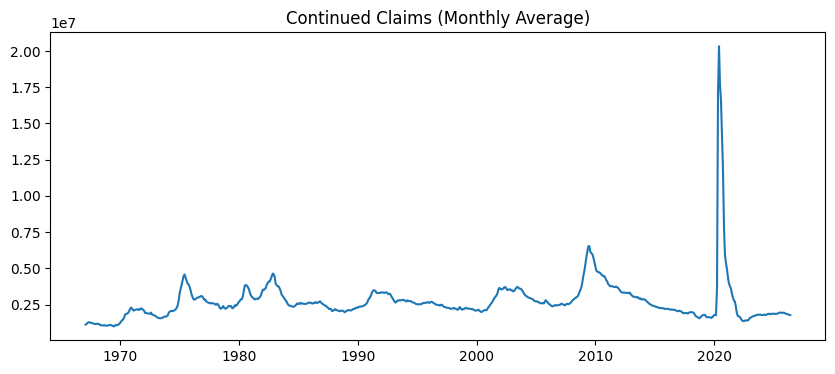

In [7]:
# --- pull continued claims ---
ccsa_raw = get_series('CCSA', 'continued_claims', '../data/continued_claims.csv')
ccsa_monthly = resample_to_monthly(ccsa_raw, method='mean')
ccsa_monthly.name = 'continued_claims_monthly'

print("--- weekly (raw) ---")
print(ccsa_raw.head(10))

print("--- monthly (resampled) ---")
print(ccsa_monthly.head(10))

# quick plot to eyeball trend/spikes before deciding on stationarity transform
plt.figure(figsize=(10, 4))
plt.plot(ccsa_monthly)
plt.title('Continued Claims (Monthly Average)')
plt.show()

In [ ]:
#check stationarity - run ADF test

from statsmodels.tsa.stattools import adfuller

result = adfuller(ccsa_monthly.dropna())
print(f"ADF statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

#We refect the null hypothesis, so statistically the series is stationary (but we know the ADF has many problems)

ADF statistic: -5.9198
p-value: 0.0000


## Initial claims (ICSA)

- We must resample the weekly data to monthly, by taking the mean value from the weekly recordings for each month (works here as well)
- Check stationarity



initial_claims: 0 missing values
--- weekly (raw) ---
1967-01-07    208000.0
1967-01-14    207000.0
1967-01-21    217000.0
1967-01-28    204000.0
1967-02-04    216000.0
1967-02-11    229000.0
1967-02-18    229000.0
1967-02-25    242000.0
1967-03-04    310000.0
1967-03-11    241000.0
Name: initial_claims, dtype: float64
--- monthly (resampled) ---
1967-01-31    209000.0
1967-02-28    229000.0
1967-03-31    260750.0
1967-04-30    263000.0
1967-05-31    235750.0
1967-06-30    232000.0
1967-07-31    227800.0
1967-08-31    212750.0
1967-09-30    216400.0
1967-10-31    216750.0
Freq: ME, Name: initial_claims_monthly, dtype: float64


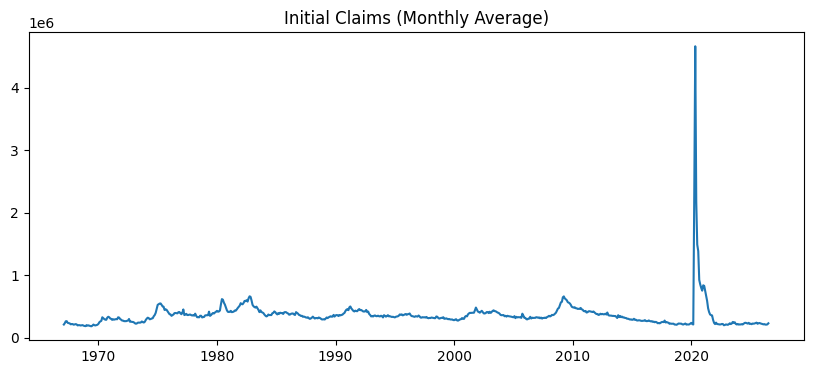

ADF statistic: -6.3635
p-value: 0.0000


In [10]:
# --- pull initial claims ---
icsa_raw = get_series('ICSA', 'initial_claims', '../data/initial_claims.csv')
icsa_monthly = resample_to_monthly(icsa_raw, method='mean')
icsa_monthly.name = 'initial_claims_monthly'

print("--- weekly (raw) ---")
print(icsa_raw.head(10))

print("--- monthly (resampled) ---")
print(icsa_monthly.head(10))

# quick plot to eyeball trend/spikes before deciding on stationarity transform
plt.figure(figsize=(10, 4))
plt.plot(icsa_monthly)
plt.title('Initial Claims (Monthly Average)')
plt.show()


#check stationarity - run ADF test

from statsmodels.tsa.stattools import adfuller

result = adfuller(icsa_monthly.dropna())
print(f"ADF statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

#check the result before assuming - don't carry over the CCSA conclusion automatically

ccsa_monthly.to_csv('../data/processed/continued_claims_monthly.csv', header=True)
icsa_monthly.to_csv('../data/processed/initial_claims_monthly.csv', header=True)

## Moody's Seasoned Baa Corporate Bond Yield Relative to Yield on 10-Year Treasury Constant Maturity (BAA10Y)

- Take end-of-month value 
- Already statistically stationary, we avoid over-differencing


baa10y_spread: 440 missing values
1986-01-20   NaN
1986-02-17   NaN
1986-03-28   NaN
1986-05-26   NaN
1986-07-04   NaN
              ..
2026-01-01   NaN
2026-01-19   NaN
2026-02-16   NaN
2026-04-03   NaN
2026-05-25   NaN
Name: baa10y_spread, Length: 440, dtype: float64
--- daily (raw) ---
1986-01-02    2.34
1986-01-03    2.30
1986-01-06    2.29
1986-01-07    2.35
1986-01-08    2.21
1986-01-09    2.16
1986-01-10    2.06
1986-01-13    2.03
1986-01-14    2.03
1986-01-15    2.20
Name: baa10y_spread, dtype: float64
--- monthly (resampled) ---
1986-01-31    2.29
1986-02-28    2.49
1986-03-31    2.92
1986-04-30    2.78
1986-05-31    2.36
1986-06-30    2.81
1986-07-31    2.91
1986-08-31    3.07
1986-09-30    2.75
1986-10-31    2.82
Freq: ME, Name: baa10y_monthly, dtype: float64
date range: 1986-01-02 00:00:00 to 2026-06-15 00:00:00


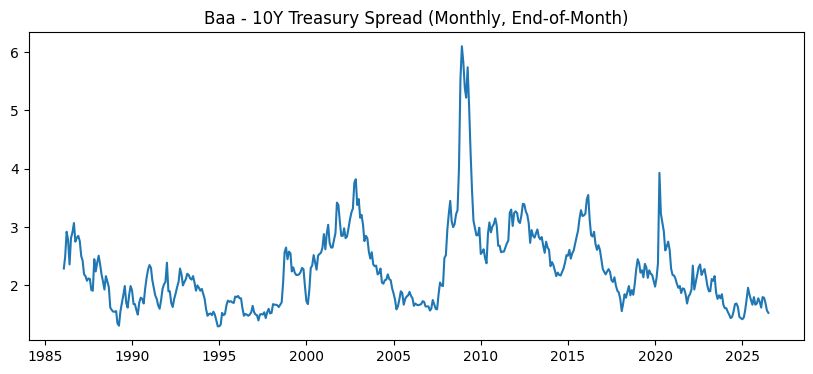

ADF statistic: -3.8390
p-value: 0.0025


In [13]:
# --- pull Baa - 10yr Treasury credit spread (longer history than ICE BofA OAS) ---
baa10y_raw = get_series('BAA10Y', 'baa10y_spread', '../data/baa10y_spread.csv')
baa10y_monthly = resample_to_monthly(baa10y_raw, method='last')
baa10y_monthly.name = 'baa10y_monthly'

print("--- daily (raw) ---")
print(baa10y_raw.head(10))

print("--- monthly (resampled) ---")
print(baa10y_monthly.head(10))

print("date range:", baa10y_raw.index.min(), "to", baa10y_raw.index.max())

plt.figure(figsize=(10, 4))
plt.plot(baa10y_monthly)
plt.title('Baa - 10Y Treasury Spread (Monthly, End-of-Month)')
plt.show()

from statsmodels.tsa.stattools import adfuller

result = adfuller(baa10y_monthly.dropna())
print(f"ADF statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

baa10y_monthly.to_csv('../data/processed/baa10y_monthly.csv', header=True)

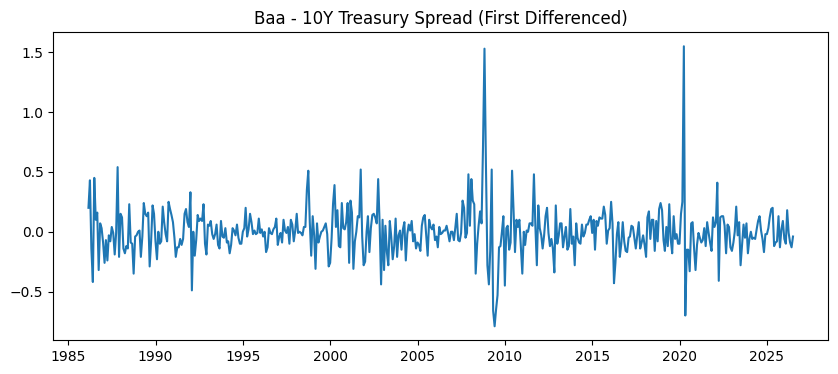

ADF statistic (first differenced): -18.5127
p-value (first differenced): 0.0000
--- comparison ---
level:      ADF=-3.8390, p=0.0025
first diff: ADF=-18.5127, p=0.0000


In [ ]:
import numpy as np

# first difference of the monthly spread
baa10y_diff = baa10y_monthly.diff().dropna()

plt.figure(figsize=(10, 4))
plt.plot(baa10y_diff)
plt.title('Baa - 10Y Treasury Spread (First Differenced)')
plt.show()

result_diff = adfuller(baa10y_diff)
print(f"ADF statistic (first differenced): {result_diff[0]:.4f}")
print(f"p-value (first differenced): {result_diff[1]:.4f}")

print("--- comparison ---")
print(f"level:      ADF={result[0]:.4f}, p={result[1]:.4f}")
print(f"first diff: ADF={result_diff[0]:.4f}, p={result_diff[1]:.4f}")

#OVER-DIFFERENCING, IGNORE

## Chicago Fed National Financial Conditions Index (NFCI)
- Stationary and we take end-of-month

nfci: 0 missing values
--- weekly (raw) ---
1971-01-08    0.597
1971-01-15    0.628
1971-01-22    0.665
1971-01-29    0.706
1971-02-05    0.749
1971-02-12    0.792
1971-02-19    0.834
1971-02-26    0.876
1971-03-05    0.919
1971-03-12    0.966
Name: nfci, dtype: float64
--- monthly (resampled) ---
1971-01-31    0.706
1971-02-28    0.876
1971-03-31    1.077
1971-04-30    1.418
1971-05-31    1.393
1971-06-30    1.028
1971-07-31    1.253
1971-08-31    2.027
1971-09-30    2.188
1971-10-31    1.575
Freq: ME, Name: nfci_monthly, dtype: float64
date range: 1971-01-08 00:00:00 to 2026-06-12 00:00:00


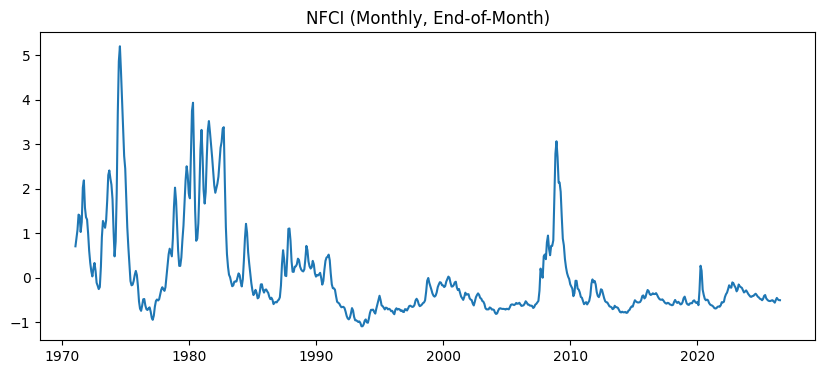

ADF statistic: -3.6038
p-value: 0.0057


In [17]:
# --- pull NFCI ---
nfci_raw = get_series('NFCI', 'nfci', '../data/nfci.csv')
nfci_monthly = resample_to_monthly(nfci_raw, method='last')
nfci_monthly.name = 'nfci_monthly'

print("--- weekly (raw) ---")
print(nfci_raw.head(10))

print("--- monthly (resampled) ---")
print(nfci_monthly.head(10))

print("date range:", nfci_raw.index.min(), "to", nfci_raw.index.max())

plt.figure(figsize=(10, 4))
plt.plot(nfci_monthly)
plt.title('NFCI (Monthly, End-of-Month)')
plt.show()

from statsmodels.tsa.stattools import adfuller

result = adfuller(nfci_monthly.dropna())
print(f"ADF statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

nfci_monthly.to_csv('../data/processed/nfci_monthly.csv', header=True)


## Yield curve - 10-Year Treasury Constant Maturity Minus 2-Year Treasury Constant Maturity (T10Y2Y)

t10y2y: 549 missing values
1976-07-05   NaN
1976-09-06   NaN
1976-10-11   NaN
1976-11-02   NaN
1976-11-11   NaN
              ..
2025-12-25   NaN
2026-01-01   NaN
2026-01-19   NaN
2026-02-16   NaN
2026-05-25   NaN
Name: t10y2y, Length: 549, dtype: float64
--- daily (raw) ---
1976-06-01    0.68
1976-06-02    0.71
1976-06-03    0.70
1976-06-04    0.77
1976-06-07    0.79
1976-06-08    0.79
1976-06-09    0.82
1976-06-10    0.86
1976-06-11    0.83
1976-06-14    0.83
Name: t10y2y, dtype: float64
--- monthly (resampled) ---
1976-06-30    0.84
1976-07-31    1.12
1976-08-31    1.16
1976-09-30    1.22
1976-10-31    1.39
1976-11-30    1.59
1976-12-31    1.47
1977-01-31    1.22
1977-02-28    1.37
1977-03-31    1.41
Freq: ME, Name: t10y2y_monthly, dtype: float64
date range: 1976-06-01 00:00:00 to 2026-06-16 00:00:00


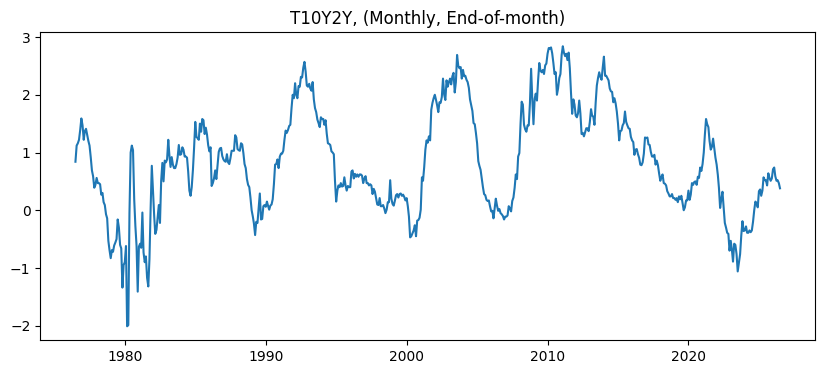

ADF statistic: -3.6368
p-value: 0.0051


In [18]:


# --- pull yield curve (10Y - 2Y) ---
t10y2y_raw = get_series("T10Y2Y", "t10y2y", '../data/t10y2y.csv' )              # ticker, name, filepath
t10y2y_monthly = resample_to_monthly(t10y2y_raw, method="last")  # which series, which method
t10y2y_monthly.name = "t10y2y_monthly"

print("--- daily (raw) ---")
print(t10y2y_raw.head(10))

print("--- monthly (resampled) ---")
print(t10y2y_monthly.head(10))

print("date range:", t10y2y_raw.index.min(), "to", t10y2y_raw.index.max())

plt.figure(figsize=(10, 4))
plt.plot(t10y2y_monthly)
plt.title("T10Y2Y, (Monthly, End-of-month)")
plt.show()

from statsmodels.tsa.stattools import adfuller

result = adfuller(t10y2y_monthly.dropna())
print(f"ADF statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

t10y2y_monthly.to_csv('../data/processed/t10y2y_monthly.csv', header=True)


(714, 5)
1967-01-31 00:00:00 1967-01-31 00:00:00 1986-01-31 00:00:00 1971-01-31 00:00:00 1976-06-30 00:00:00
                          continued_claims_monthly  initial_claims_monthly  \
continued_claims_monthly                  1.000000                0.777304   
initial_claims_monthly                    0.777304                1.000000   
baa10y_monthly                            0.353853                0.275261   
nfci_monthly                              0.107410                0.136152   
t10y2y_monthly                            0.297352                0.146303   

                          baa10y_monthly  nfci_monthly  t10y2y_monthly  
continued_claims_monthly        0.353853      0.107410        0.297352  
initial_claims_monthly          0.275261      0.136152        0.146303  
baa10y_monthly                  1.000000      0.535051        0.503597  
nfci_monthly                    0.535051      1.000000       -0.033540  
t10y2y_monthly                  0.503597     -0.033540   

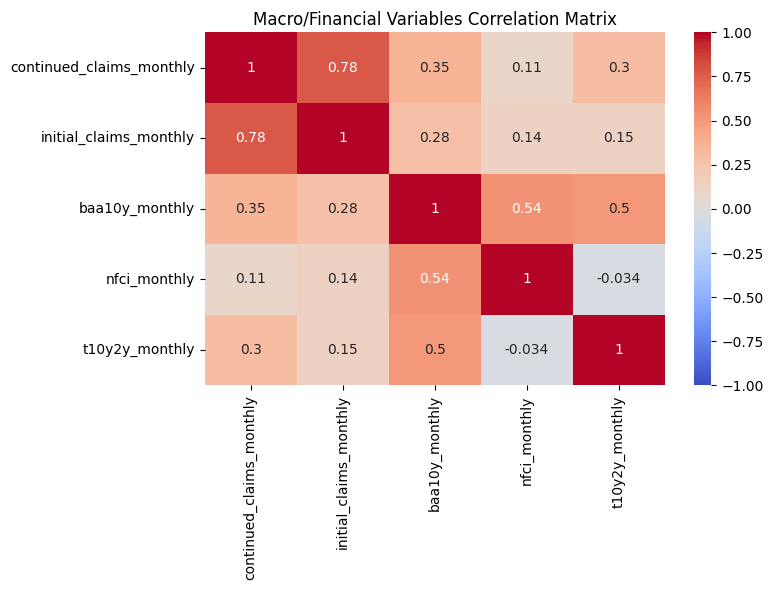

In [ ]:
macro_df = pd.concat([
    ccsa_monthly,
    icsa_monthly,
    baa10y_monthly,   # or hy_oas_monthly/ig_oas_monthly if you want to keep those too
    nfci_monthly,
    t10y2y_monthly,
], axis=1)

print(macro_df.shape)
macro_df.head(10)

print(ccsa_monthly.index.min(), icsa_monthly.index.min(), baa10y_monthly.index.min(), 
      nfci_monthly.index.min(), t10y2y_monthly.index.min())

corr_matrix = macro_df.dropna().corr()
print(corr_matrix)

import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Macro/Financial Variables Correlation Matrix')
plt.tight_layout()
plt.show()